# Social Networks Analysis Project

## Import Necessary Libraries
First, we import necessary libraries used for loading, preprocessing the data, graph visualization and data evaluation.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

## Read the data

Then, we read the dataset so that it will be utilized during the project.

In [2]:
df = pd.read_csv(
    "sx-stackoverflow.txt",
    sep=r"\s+",
    header=None,
    names=["source", "target", "timestamp"]
)

print(f"Records: {len(df):,}")
print(f"Columns: {list(df.columns)}")

Records: 63,497,050
Columns: ['source', 'target', 'timestamp']


## Recreate 10 Temporal Periods

For this notebook (and Part 2 to work), we need to recreate the 10 temporal periods used in Part 1.

In [3]:
# recreate 10 temportal periods

tmin = df["timestamp"].min()
tmax = df["timestamp"].max()

N = 10

time_points = np.linspace(tmin, tmax, N + 1)

print("Time boundaries:")
for i, t in enumerate(time_points):
    print(f"t{i} = {t}")

Time boundaries:
t0 = 1217567877.0
t1 = 1241538432.1
t2 = 1265508987.2
t3 = 1289479542.3
t4 = 1313450097.4
t5 = 1337420652.5
t6 = 1361391207.6
t7 = 1385361762.7
t8 = 1409332317.8
t9 = 1433302872.9
t10 = 1457273428.0


## Recreate 10 Undirected Temporal Graphs

Now, we need to recreate the 10 undirected temporal graphs from Part 1 including removing self loops.

In [4]:
# recreate 10 undirected temporal graphs

graphs = []

for j in range(N):
    start = time_points[j]
    end = time_points[j + 1]

    if j < N - 1:
        period_df = df[
            (df["timestamp"] >= start) &
            (df["timestamp"] < end)
        ]
    else:
        period_df = df[
            (df["timestamp"] >= start) &
            (df["timestamp"] <= end)
        ]

    G = nx.from_pandas_edgelist(
        period_df,
        source="source",
        target="target",
        create_using=nx.Graph()
    )

    G.remove_edges_from(nx.selfloop_edges(G))

    graphs.append(G)

    print(
        f"T{j+1}: "
        f"{G.number_of_nodes():,} nodes, "
        f"{G.number_of_edges():,} edges"
    )

T1: 32,888 nodes, 496,620 edges
T2: 91,139 nodes, 1,012,026 edges
T3: 187,011 nodes, 1,470,491 edges
T4: 319,421 nodes, 2,305,798 edges
T5: 423,668 nodes, 2,895,693 edges
T6: 572,267 nodes, 3,516,687 edges
T7: 748,973 nodes, 4,255,052 edges
T8: 854,705 nodes, 4,406,668 edges
T9: 928,934 nodes, 4,145,454 edges
T10: 1,024,422 nodes, 4,474,425 edges


## Create Persistent Nodes and Edges

First, we calculate the number of persistent nodes between each pair.

In [5]:
# calculate number of persistent nodes

persistent_nodes = []

for j in range(N - 1):
    common_nodes = set(graphs[j].nodes()) & set(graphs[j + 1].nodes())
    persistent_nodes.append(common_nodes)

    print(
        f"T{j+1} → T{j+2}: "
        f"{len(common_nodes):,} persistent nodes"
    )

T1 → T2: 24,781 persistent nodes
T2 → T3: 54,874 persistent nodes
T3 → T4: 95,659 persistent nodes
T4 → T5: 155,775 persistent nodes
T5 → T6: 229,295 persistent nodes
T6 → T7: 306,353 persistent nodes
T7 → T8: 379,034 persistent nodes
T8 → T9: 420,915 persistent nodes
T9 → T10: 460,709 persistent nodes


In [6]:
# calculate number of persistent edges

persistent_edges_current = []
persistent_edges_next = []

for j in range(N - 1):
    common_nodes = persistent_nodes[j]

    current_edges = {
        tuple(sorted((u, v)))
        for u, v in graphs[j].edges()
        if u in common_nodes and v in common_nodes
    }

    next_edges = {
        tuple(sorted((u, v)))
        for u, v in graphs[j + 1].edges()
        if u in common_nodes and v in common_nodes
    }

    persistent_edges_current.append(current_edges)
    persistent_edges_next.append(next_edges)

    print(
        f"T{j+1} → T{j+2}: "
        f"|E*_{j+1}| = {len(current_edges):,}, "
        f"|E*_{j+2}| = {len(next_edges):,}"
    )

T1 → T2: |E*_1| = 453,910, |E*_2| = 298,615
T2 → T3: |E*_2| = 873,542, |E*_3| = 579,638
T3 → T4: |E*_3| = 1,193,006, |E*_4| = 865,608
T4 → T5: |E*_4| = 1,804,880, |E*_5| = 1,243,077
T5 → T6: |E*_5| = 2,303,640, |E*_6| = 1,624,896
T6 → T7: |E*_6| = 2,694,295, |E*_7| = 1,961,770
T7 → T8: |E*_7| = 3,064,149, |E*_8| = 2,171,307
T8 → T9: |E*_8| = 2,987,829, |E*_9| = 2,048,912
T9 → T10: |E*_9| = 2,756,422, |E*_10| = 2,191,718


## Plot Persistent Nodes and Restricted Edges

We plot persistent nodes and restricted edges.

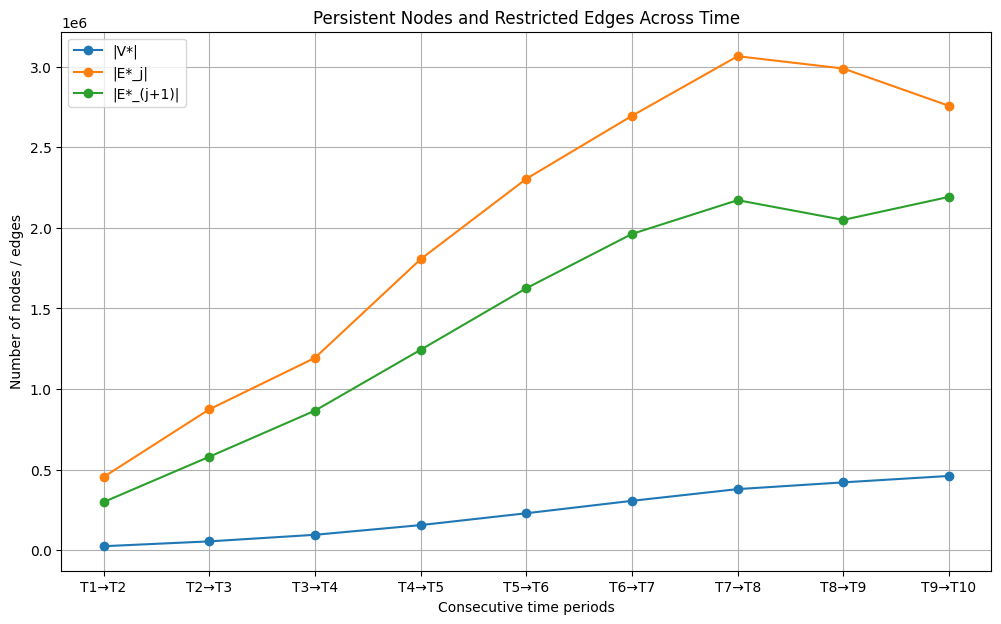

In [7]:
# plot persistent nodes and restricted edges

period_pairs = [f"T{j+1}→T{j+2}" for j in range(N - 1)]

persistent_node_counts = [
    len(nodes) for nodes in persistent_nodes
]

current_edge_counts = [
    len(edges) for edges in persistent_edges_current
]

next_edge_counts = [
    len(edges) for edges in persistent_edges_next
]

x = np.arange(len(period_pairs))

plt.figure(figsize=(12, 7))

plt.plot(
    x,
    persistent_node_counts,
    marker="o",
    label="|V*|"
)

plt.plot(
    x,
    current_edge_counts,
    marker="o",
    label="|E*_j|"
)

plt.plot(
    x,
    next_edge_counts,
    marker="o",
    label="|E*_(j+1)|"
)

plt.xticks(x, period_pairs)
plt.xlabel("Consecutive time periods")
plt.ylabel("Number of nodes / edges")
plt.title("Persistent Nodes and Restricted Edges Across Time")
plt.legend()
plt.grid(True)
plt.show()

## Similarity Measures

For each consecutive pair of periods, similarity scores are calculated for candidate pairs of persistent nodes.
We use a fixed number of pairs to reduce computational cost.

The similarity measures are:

- SGD — negative geodesic distance
- SCN — common neighbors
- SJC — Jaccard similarity of common neighbors
- SA — Adamic/Adar similarity
- SPA — preferential attachment

In [10]:
# calculate SGD

G_current = graphs[0].subgraph(persistent_nodes[0])

nodes = np.asarray(list(G_current.nodes()), dtype=np.int64)

np.random.seed(42)

num_pairs = 100_000

sampled_u = np.random.choice(nodes, size=num_pairs)
sampled_v = np.random.choice(nodes, size=num_pairs)

# Remove self-pairs
mask = sampled_u != sampled_v

sampled_u = sampled_u[mask]
sampled_v = sampled_v[mask]

print(f"Sampled pairs: {len(sampled_u):,}")

Sampled pairs: 99,995


In [11]:
# avoid duplicate pairs
pairs = set()

while len(pairs) < num_pairs:
    u, v = np.random.choice(nodes, size=2, replace=False)

    if u > v:
        u, v = v, u

    pairs.add((u, v))

pairs = np.asarray(list(pairs), dtype=np.int64)

sampled_u = pairs[:, 0]
sampled_v = pairs[:, 1]

print(f"Unique sampled pairs: {len(pairs):,}")

Unique sampled pairs: 100,000


In [14]:
# calculate exact shortest paths for those pairs

G_current = graphs[0].subgraph(persistent_nodes[0])

nodes = np.asarray(list(G_current.nodes()), dtype=np.int64)

np.random.seed(42)

num_sources = 500
targets_per_source = 200

sampled_sources = np.random.choice(
    nodes,
    size=num_sources,
    replace=False
)

sgd_u = []
sgd_v = []
sgd_values = []

for source in sampled_sources:

    distances = nx.single_source_shortest_path_length(
        G_current,
        int(source)
    )

    available_targets = np.array(
        [node for node in distances if node != source],
        dtype=np.int64
    )

    if len(available_targets) > targets_per_source:
        targets = np.random.choice(
            available_targets,
            size=targets_per_source,
            replace=False
        )
    else:
        targets = available_targets

    for target in targets:
        sgd_u.append(source)
        sgd_v.append(target)
        sgd_values.append(-distances[int(target)])

sgd_u = np.asarray(sgd_u, dtype=np.int64)
sgd_v = np.asarray(sgd_v, dtype=np.int64)
sgd_array = np.asarray(sgd_values, dtype=np.int16)

print(f"SGD pairs: {len(sgd_array):,}")

SGD pairs: 99,400


In [15]:
# calculate SCN
scn_array = np.empty(len(sgd_u), dtype=np.int32)

for i, (u, v) in enumerate(zip(sgd_u, sgd_v)):
    neighbors_u = set(G_current.neighbors(int(u)))
    neighbors_v = set(G_current.neighbors(int(v)))

    scn_array[i] = len(neighbors_u & neighbors_v)

print(f"SCN pairs: {len(scn_array):,}")

SCN pairs: 99,400


In [16]:
# calculate SJC
sjc_array = np.empty(len(sgd_u), dtype=np.float32)

for i, (u, v) in enumerate(zip(sgd_u, sgd_v)):
    neighbors_u = set(G_current.neighbors(int(u)))
    neighbors_v = set(G_current.neighbors(int(v)))

    intersection = len(neighbors_u & neighbors_v)
    union = len(neighbors_u | neighbors_v)

    sjc_array[i] = intersection / union if union > 0 else 0

print(f"SJC pairs: {len(sjc_array):,}")

SJC pairs: 99,400


In [17]:
# calculate SA

sa_array = np.empty(len(sgd_u), dtype=np.float32)

degrees = dict(G_current.degree())

for i, (u, v) in enumerate(zip(sgd_u, sgd_v)):

    common_neighbors = (
        set(G_current.neighbors(int(u))) &
        set(G_current.neighbors(int(v)))
    )

    score = 0.0

    for z in common_neighbors:
        degree = degrees[z]

        if degree > 1:
            score += 1 / np.log(degree)

    sa_array[i] = score

print(f"SA pairs: {len(sa_array):,}")

SA pairs: 99,400


In [18]:
# calculate SPA

spa_array = np.empty(len(sgd_u), dtype=np.int64)

degrees = dict(G_current.degree())

for i, (u, v) in enumerate(zip(sgd_u, sgd_v)):
    spa_array[i] = degrees[int(u)] * degrees[int(v)]

print(f"SPA pairs: {len(spa_array):,}")

SPA pairs: 99,400
